In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("./data/train.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
df.shape

(891, 12)

In [9]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [10]:
df.isnull().sum().sort_values(ascending=False)

Cabin          687
Age            177
Embarked         2
PassengerId      0
Name             0
Pclass           0
Survived         0
Sex              0
Parch            0
SibSp            0
Fare             0
Ticket           0
dtype: int64

In [13]:
missing = df.isnull().sum()

missing_percent = (missing / len(df)) * 100

missing_percent.sort_values(ascending=False)

Cabin          77.104377
Age            19.865320
Embarked        0.224467
PassengerId     0.000000
Name            0.000000
Pclass          0.000000
Survived        0.000000
Sex             0.000000
Parch           0.000000
SibSp           0.000000
Fare            0.000000
Ticket          0.000000
dtype: float64

In [14]:
df.nunique()

PassengerId    891
Survived         2
Pclass           3
Name           891
Sex              2
Age             88
SibSp            7
Parch            7
Ticket         681
Fare           248
Cabin          147
Embarked         3
dtype: int64

In [16]:
df["Sex"].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

In [17]:
df["Pclass"].value_counts()

Pclass
3    491
1    216
2    184
Name: count, dtype: int64

In [18]:
df["Embarked"].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

<Axes: title={'center': 'Sex Distribution'}, xlabel='Sex', ylabel='Count'>

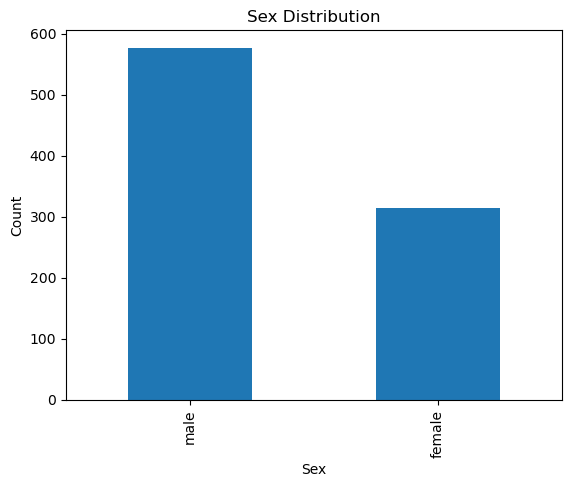

In [21]:
df["Sex"].value_counts().plot(kind="bar", title="Sex Distribution", xlabel="Sex", ylabel="Count")

<Axes: title={'center': 'Embarked Distribution'}, xlabel='Embarked', ylabel='Count'>

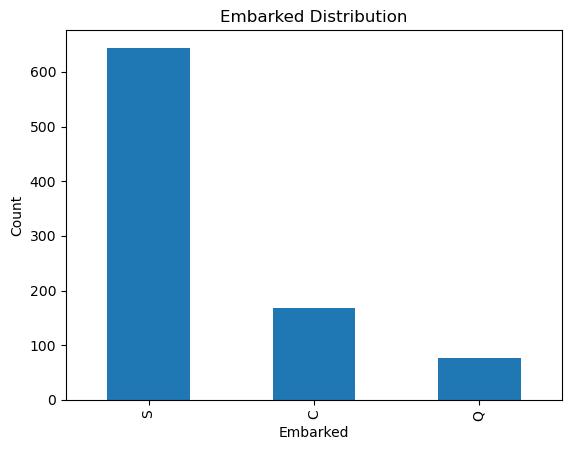

In [22]:
df["Embarked"].value_counts().plot(kind="bar", title="Embarked Distribution", xlabel="Embarked", ylabel="Count")

<Axes: title={'center': 'Pclass Distribution'}, xlabel='Pclass', ylabel='Count'>

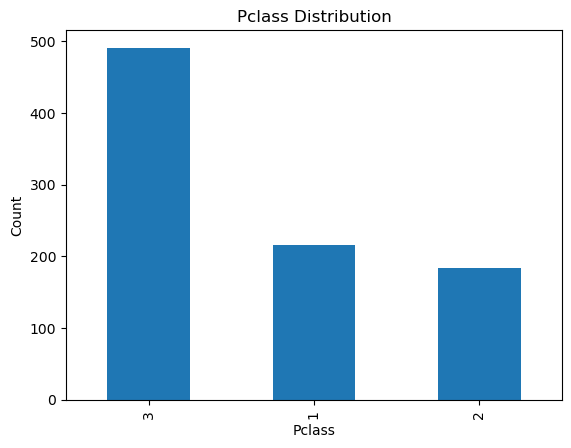

In [23]:
df["Pclass"].value_counts().plot(kind="bar", title="Pclass Distribution", xlabel="Pclass", ylabel="Count")

In [25]:
df["Age"].value_counts()

Age
24.00    30
22.00    27
18.00    26
28.00    25
30.00    25
         ..
24.50     1
0.67      1
0.42      1
34.50     1
74.00     1
Name: count, Length: 88, dtype: int64

<Axes: title={'center': 'Age Distribution'}, xlabel='Age', ylabel='Count'>

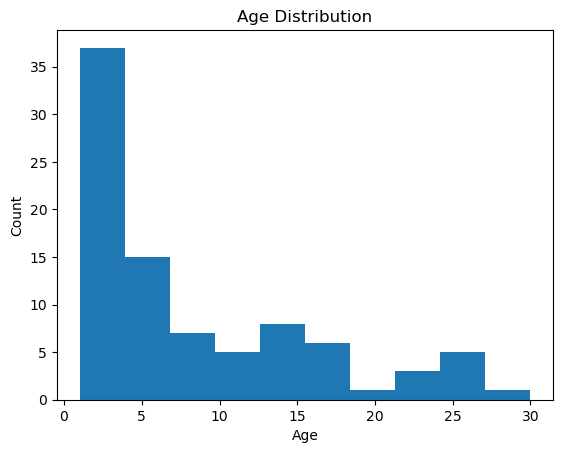

In [24]:
df["Age"].value_counts().plot(kind="hist", title="Age Distribution", xlabel="Age", ylabel="Count")

In [26]:
pd.crosstab(df["Sex"], df["Survived"])

Survived,0,1
Sex,,
female,81,233
male,468,109


In [27]:
pd.crosstab(df["Sex"], df["Survived"], normalize="index") * 100

Survived,0,1
Sex,,
female,25.796178,74.203822
male,81.109185,18.890815


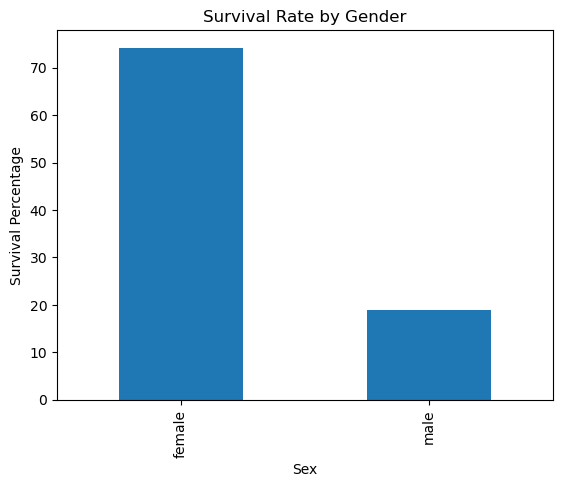

In [28]:
survival_rate = pd.crosstab(
    df["Sex"],
    df["Survived"],
    normalize="index"
) * 100

survival_rate[1].plot(kind="bar")
plt.title("Survival Rate by Gender")
plt.ylabel("Survival Percentage")
plt.show()

In [29]:
pd.crosstab(df["Pclass"], df["Survived"])

Survived,0,1
Pclass,,
1,80,136
2,97,87
3,372,119


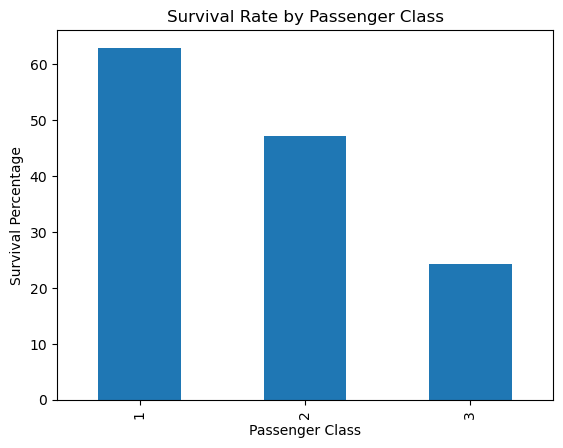

In [30]:
pclass_survival_rate = pd.crosstab(
    df["Pclass"],
    df["Survived"],
    normalize="index"
) * 100

pclass_survival_rate[1].plot(kind="bar")
plt.title("Survival Rate by Passenger Class")
plt.ylabel("Survival Percentage")
plt.xlabel("Passenger Class")
plt.show()

In [31]:
pd.crosstab(df["Age"],df["Survived"])

Survived,0,1
Age,,
0.42,0,1
0.67,0,1
0.75,0,2
0.83,0,2
0.92,0,1
...,...,...
70.00,2,0
70.50,1,0
71.00,2,0


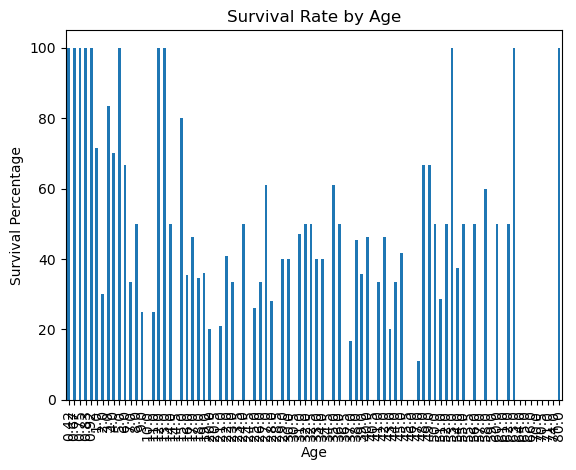

In [34]:
age_survival_rate = pd.crosstab(
    df["Age"],
    df["Survived"],
    normalize="index"
) * 100
age_survival_rate[1].plot(kind="bar")
plt.title("Survival Rate by Age")
plt.ylabel("Survival Percentage")
plt.xlabel("Age")
plt.show()

In [43]:
pd.crosstab(df["Fare"],df["Survived"])

Survived,0,1
Fare,,
0.0000,14,1
4.0125,1,0
5.0000,1,0
6.2375,1,0
6.4375,1,0
...,...,...
227.5250,1,3
247.5208,1,1
262.3750,0,2


In [44]:
df["Fare_Group"] = pd.qcut(df["Fare"], q=4)

In [45]:
df["Fare_Group"].value_counts()

Fare_Group
(7.91, 14.454]     224
(-0.001, 7.91]     223
(14.454, 31.0]     222
(31.0, 512.329]    222
Name: count, dtype: int64

In [46]:
fare_survival = pd.crosstab(
    df["Fare_Group"],
    df["Survived"],
    normalize="index"
) * 100

fare_survival

Survived,0,1
Fare_Group,,
"(-0.001, 7.91]",80.269058,19.730942
"(7.91, 14.454]",69.642857,30.357143
"(14.454, 31.0]",54.504505,45.495495
"(31.0, 512.329]",41.891892,58.108108


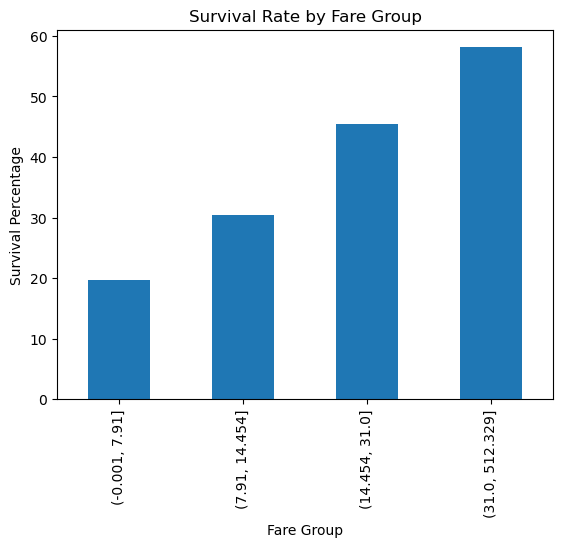

In [47]:
fare_survival[1].plot(kind="bar")

plt.title("Survival Rate by Fare Group")
plt.xlabel("Fare Group")
plt.ylabel("Survival Percentage")
plt.show()

In [48]:
pd.crosstab(df["Age"], df["Survived"])

Survived,0,1
Age,,
0.42,0,1
0.67,0,1
0.75,0,2
0.83,0,2
0.92,0,1
...,...,...
70.00,2,0
70.50,1,0
71.00,2,0


In [49]:
df["Age_Group"] = pd.cut(
    df["Age"],
    bins=[0, 12, 18, 35, 60, 100],
    labels=["Child", "Teen", "Young Adult", "Adult", "Senior"]
)

In [50]:
df["Age_Group"].value_counts()

Age_Group
Young Adult    358
Adult          195
Teen            70
Child           69
Senior          22
Name: count, dtype: int64

In [51]:
age_survival = pd.crosstab(
    df["Age_Group"],
    df["Survived"],
    normalize="index"
) * 100

age_survival

Survived,0,1
Age_Group,,
Child,42.028986,57.971014
Teen,57.142857,42.857143
Young Adult,61.731844,38.268156
Adult,60.000000,40.000000
Senior,77.272727,22.727273


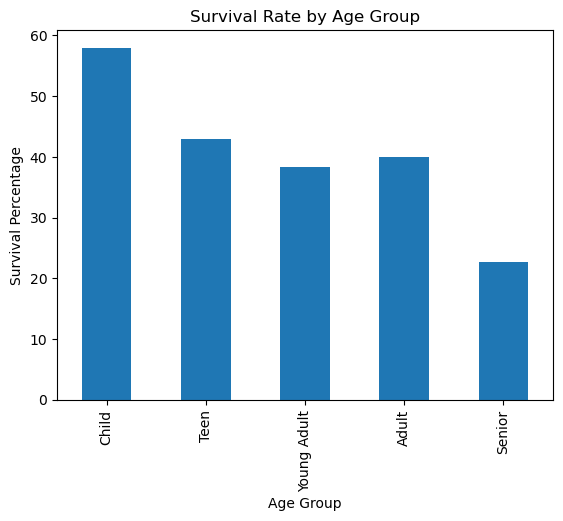

In [58]:
age_survival[1].plot(kind="bar")

plt.title("Survival Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Survival Percentage")
plt.show()

In [53]:
df.corr(numeric_only=True)

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.005007,-0.035144,0.036847,-0.057527,-0.001652,0.012658
Survived,-0.005007,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
Pclass,-0.035144,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
Age,0.036847,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.057527,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
Parch,-0.001652,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
Fare,0.012658,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


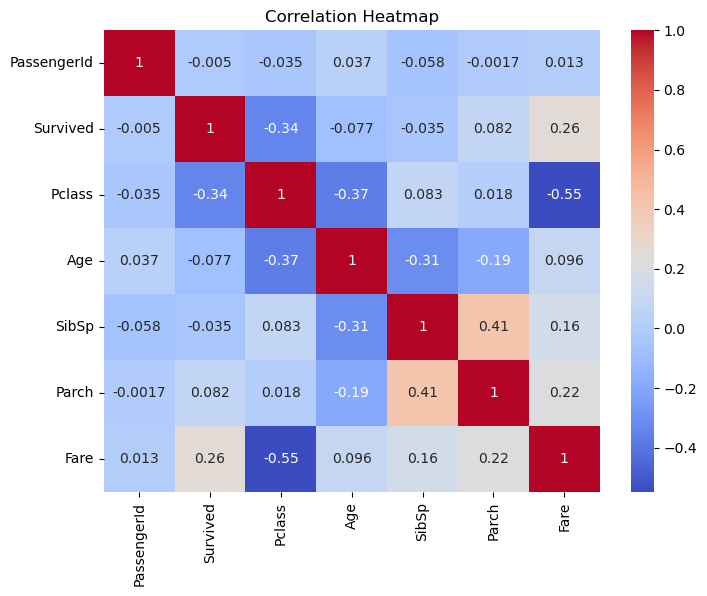

In [56]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()